#Data Loading & Exploration


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv("/content/archive (28).csv")

In [ ]:
first_10_rows = df.head(10)
first_10_rows

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
rows, columns = df.shape

In [ ]:
target_column = "Attrition"

In [ ]:
attrition_count = df["Attrition"].value_counts()
attrition_count

,count
Attrition,
No,1233
Yes,237


In [ ]:
attrition_rate = round((attrition_count["Yes"] / len(df)) * 100, 2)

In [ ]:
numeric_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(exclude="number").columns

num_numeric = len(numeric_columns)
num_categorical = len(categorical_columns)

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Employees Stayed",
        "Employees Left",
        "Attrition Rate (%)",
        "Numeric Columns",
        "Categorical Columns"
    ],
    "Value": [
        rows,
        columns,
        attrition_count["No"],
        attrition_count["Yes"],
        attrition_rate,
        num_numeric,
        num_categorical
    ]
})

summary

,Metric,Value
0,Total Rows,1470.00
1,Total Columns,35.00
2,Employees Stayed,1233.00
3,Employees Left,237.00
4,Attrition Rate (%),16.12
5,Numeric Columns,26.00
6,Categorical Columns,9.00


#Observation:

Most employees stayed in the company, while only a small number left.
The attrition rate is 16.12%, which means the dataset is imbalanced because
the number of employees who stayed is much higher than those who left.

#Data Cleaning & Preprocessing

In [ ]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [ ]:
df = df.drop(columns=[
    "EmployeeNumber",
    "Over18",
    "StandardHours",
    "EmployeeCount"
])

In [ ]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [ ]:
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

In [ ]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)


In [ ]:
X_scaled.shape

(1470, 44)

#Exploratory Data Analysis (EDA)

In [ ]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

department_attrition

,Attrition
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750


In [ ]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

jobrole_attrition

,Attrition
JobRole,
Sales Representative,39.759036
Laboratory Technician,23.938224
Human Resources,23.076923
Sales Executive,17.484663
Research Scientist,16.095890
Manufacturing Director,6.896552
Healthcare Representative,6.870229
Manager,4.901961
Research Director,2.500000


In [ ]:
income_attrition = (
    df.groupby("Attrition")["MonthlyIncome"]
      .mean()
)

income_attrition

,MonthlyIncome
Attrition,
0,6832.739659
1,4787.092827


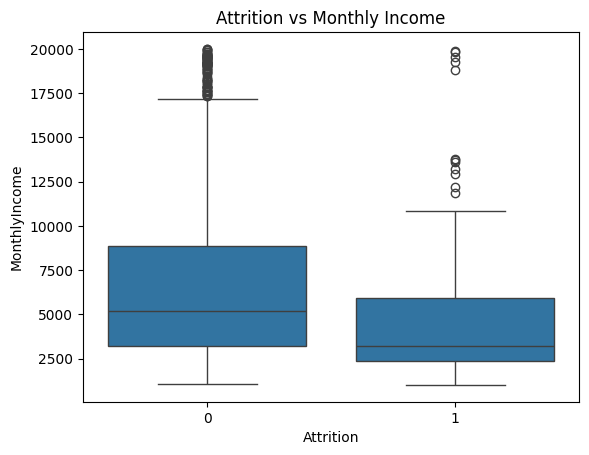

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Attrition vs Monthly Income")
plt.show()

In [ ]:
worklife_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .mean() * 100
)

worklife_attrition

,Attrition
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059


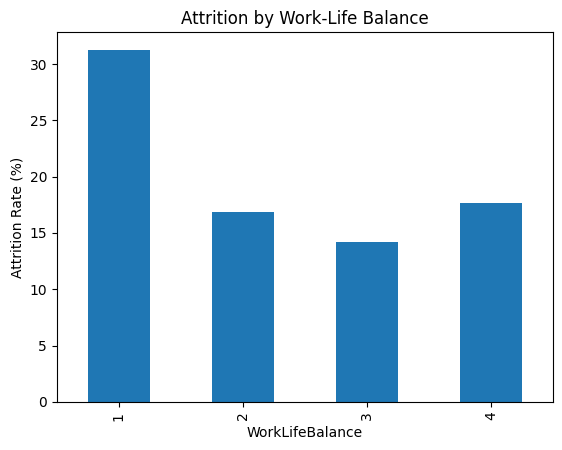

In [ ]:
worklife_attrition.plot(kind="bar")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition by Work-Life Balance")
plt.show()

In [ ]:
years_attrition = (
    df.groupby("YearsAtCompany")["Attrition"]
      .mean() * 100
)

years_attrition

,Attrition
YearsAtCompany,
0,36.363636
1,34.502924
2,21.259843
3,15.625000
4,17.272727
5,10.714286
6,11.842105
7,12.222222
8,11.250000


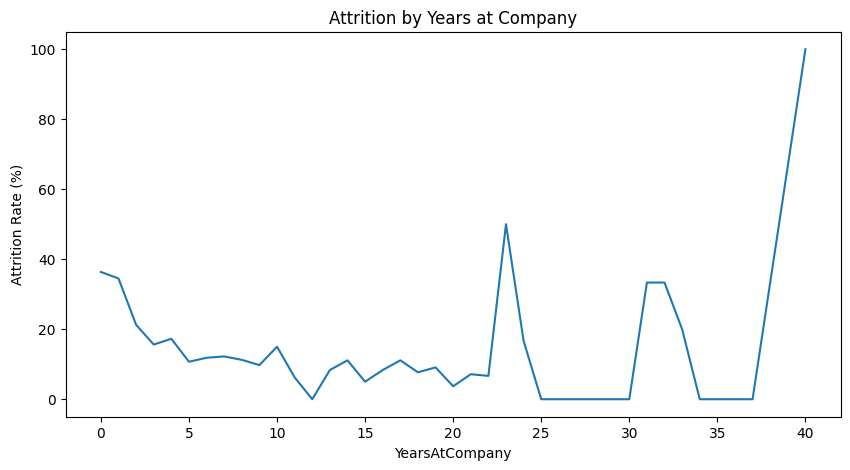

In [ ]:
years_attrition.plot(figsize=(10,5))
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition by Years at Company")
plt.show()

#insights

1>Employees in the Sales department have the highest attrition rate (around 20%), while Research & Development has a lower attrition rate.

2>Among job roles, Sales Representatives and Laboratory Technicians leave the company most frequently, with attrition rates above 20%.

3>Employees who leave the company generally have a lower average monthly income compared to employees who stay, suggesting compensation may influence retention.

4>Attrition tends to be higher among employees with lower Work-Life Balance ratings (1 or 2). Employees reporting better work-life balance are more likely to stay.

5>Most employee exits occur during the first 1–3 years at the company. Attrition decreases significantly as employee tenure increases, indicating that retaining new employees should be a priority.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [ ]:
random_forest = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

In [ ]:
gradient_boost = GradientBoostingClassifier(
    random_state=42
)


In [ ]:
log_reg.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
gradient_boost.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
lr_pred = log_reg.predict(X_test)
rf_pred = random_forest.predict(X_test)
gb_pred = gradient_boost.predict(X_test)

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748,0.341,0.617,0.439
1,Random Forest,0.833,0.375,0.064,0.109
2,Gradient Boosting,0.850,0.588,0.213,0.312


# Model Evaluation


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)


In [ ]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boost
}

In [ ]:
evaluation_results = []
for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    evaluation_results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

evaluation_table = pd.DataFrame(evaluation_results)

evaluation_table


Logistic Regression

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294


Confusion Matrix
[[191  56]
 [ 18  29]]

Random Forest

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294


Confusion Matrix
[[242   5]
 [ 44   3]]

Gradient Boosting

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.

,Model,ROC-AUC
0,Logistic Regression,0.798605
1,Random Forest,0.751917
2,Gradient Boosting,0.794125


In [ ]:
best_model = gradient_boost

cm = confusion_matrix(
    y_test,
    best_model.predict(X_test)
)

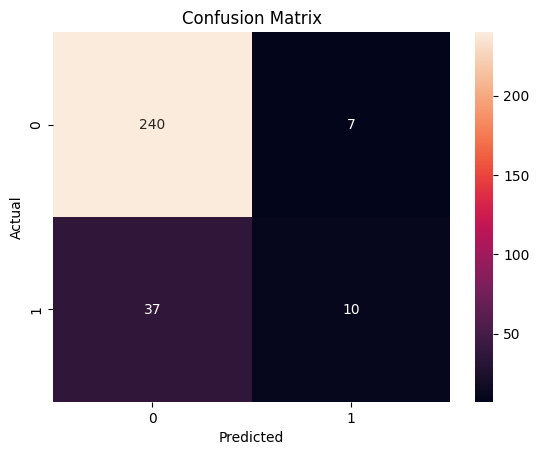

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
evaluation_table.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,ROC-AUC
0,Logistic Regression,0.798605
2,Gradient Boosting,0.794125
1,Random Forest,0.751917


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gradient_boost.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047109
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043466
4,EnvironmentSatisfaction,0.038851
6,JobInvolvement,0.038142


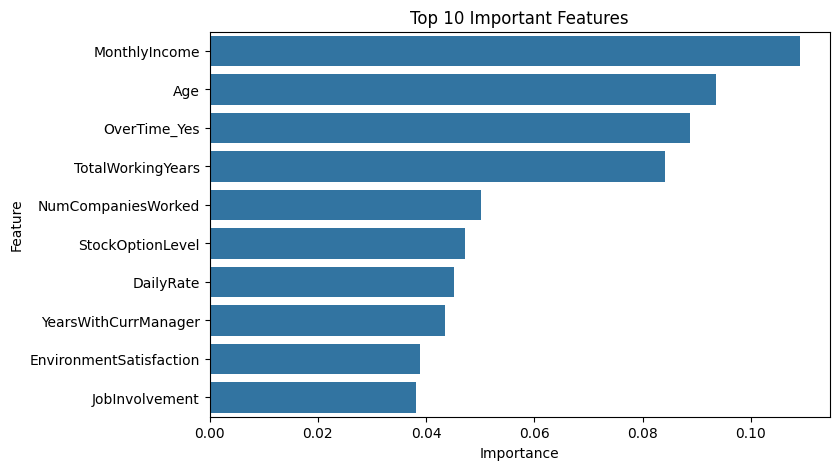

In [ ]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

#Visualization

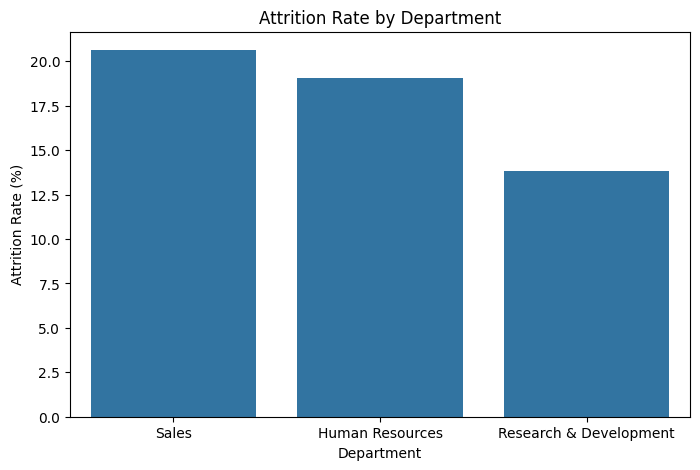

In [ ]:
department_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.show()

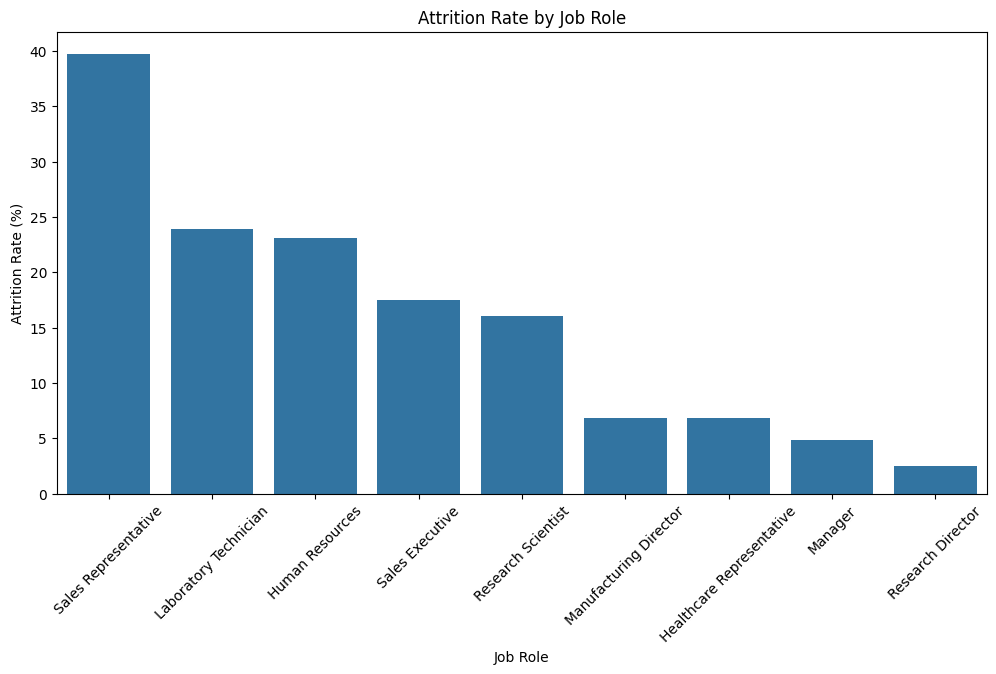

In [ ]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values
)

plt.xticks(rotation=45)
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.show()

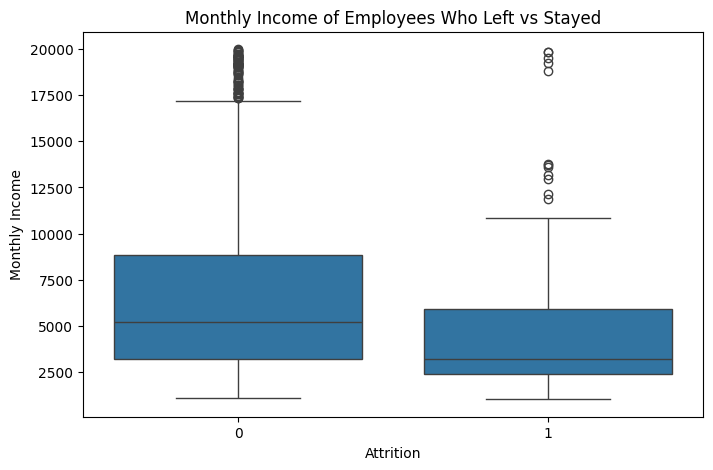

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income of Employees Who Left vs Stayed")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

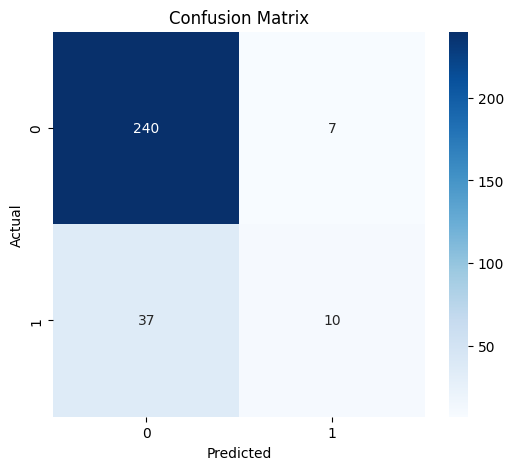

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = gradient_boost

cm = confusion_matrix(
    y_test,
    best_model.predict(X_test)
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

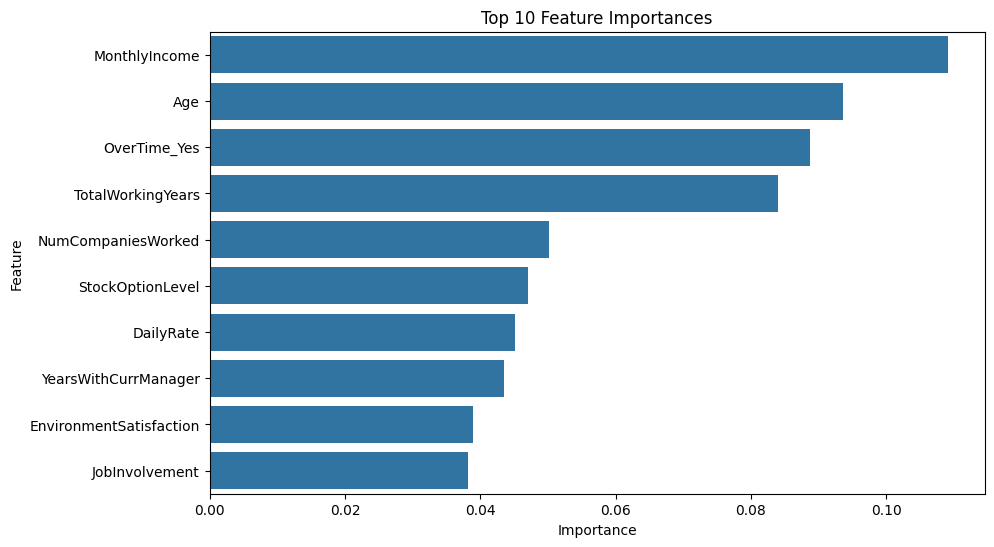

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

top10 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

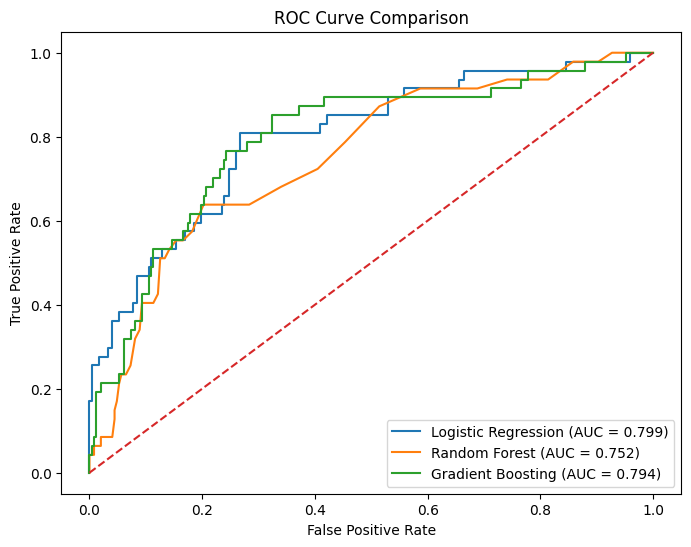

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()